# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


# Load Images

In [3]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

print("Images loaded successfully.")

Images loaded successfully.


# Concatenate

In [4]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

print("Data concatenated successfully.")

Data concatenated successfully.


# Normalization

In [5]:
All_data_normalized = All_data / 255.0

print("Data normalized successfully.")

Data normalized successfully.


# Encode & Split

In [6]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

print("Labels encoded and data split successfully.")

Labels encoded and data split successfully.


# Plot Data Distribution

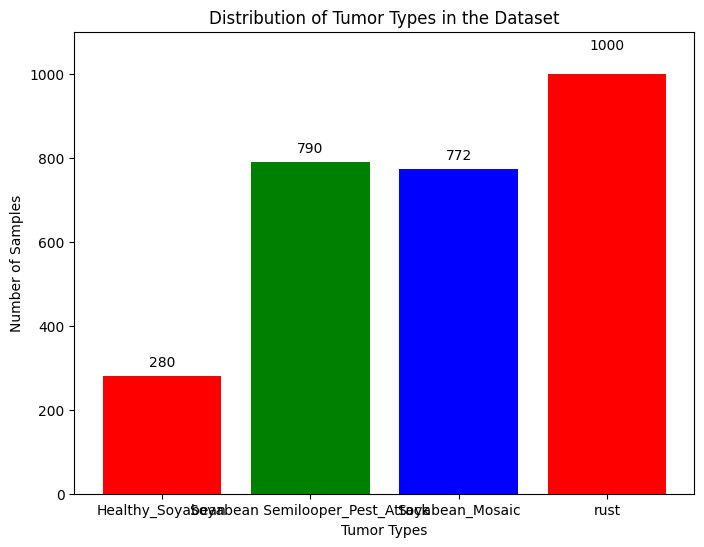

Data distribution plotted successfully.


In [7]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

print("Data distribution plotted successfully.")

# FPN Feature Extractor (C4 Only)

In [8]:
def build_c4_only_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (same 3 conv blocks, but only C4 used)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(c3)
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x32

    # Lateral 1x1 on C4 only
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)

    # No top-down fusion since C3, C5 are excluded
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(l4)

    # GAP to vector
    feat_vec = layers.GlobalAveragePooling2D(name="c4_feat")(p4)

    return models.Model(x_in, feat_vec, name="c4_only_feature_extractor")

cnn_model_c4 = build_c4_only_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model_c4.summary()

print("C4-only FPN model built successfully.")

I0000 00:00:1784389406.553166      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "c4_only_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 18)     │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 18)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         5,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c4_feat                         │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,760 (174.84 KB)

 Trainable params: 44,760 (174.84 KB)

 Non-trainable params: 0 (0.00 B)

C4-only FPN model built successfully.


# Flattened Features (C4 Only)

In [9]:
train_features_c4 = cnn_model_c4.predict(train_data, batch_size=64, verbose=0)
test_features_c4  = cnn_model_c4.predict(test_data,  batch_size=64, verbose=0)

def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features_c4 = l2_normalize(train_features_c4)
test_features_c4  = l2_normalize(test_features_c4)

train_features_c4_flattened = np.reshape(train_features_c4, (train_features_c4.shape[0], -1))
test_features_c4_flattened  = np.reshape(test_features_c4,  (test_features_c4.shape[0], -1))

print("C4-only features extracted successfully.")

I0000 00:00:1784389409.376911     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


C4-only features extracted successfully.


# Random Forest (C4 Only)

In [10]:
rf_model_c4 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model_c4.fit(train_features_c4_flattened, train_labels)

rf_pred_labels_c4 = rf_model_c4.predict(test_features_c4_flattened)
rf_pred_probs_c4  = rf_model_c4.predict_proba(test_features_c4_flattened)

print("Random Forest (C4 only) trained successfully.")

Random Forest (C4 only) trained successfully.


# Confusion Matrix

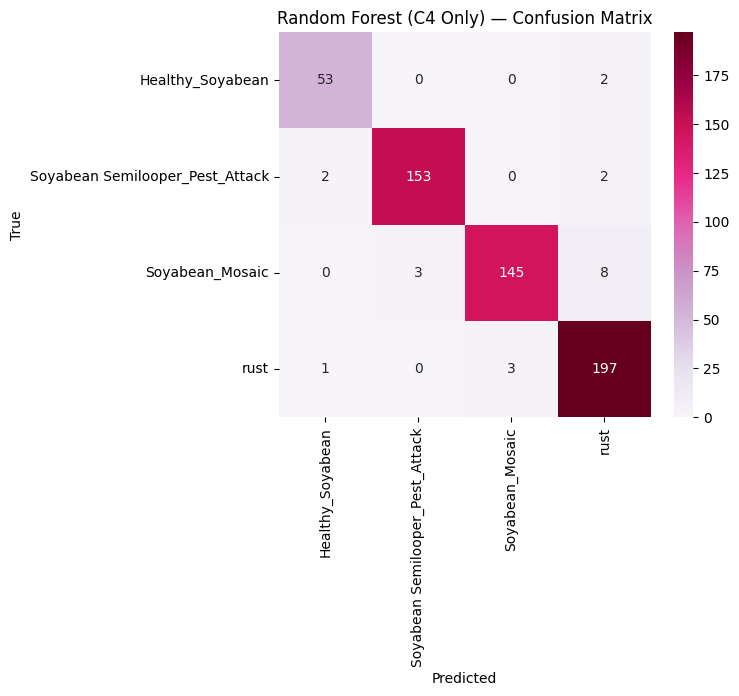

Confusion matrix plotted successfully.


In [11]:
rf_cm_c4 = confusion_matrix(test_labels, rf_pred_labels_c4)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm_c4, annot=True, fmt='d', cmap='PuRd',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Random Forest (C4 Only) — Confusion Matrix")
plt.show()

print("Confusion matrix plotted successfully.")

# Classification Report

In [12]:
print("Random Forest (C4 Only) — Classification Report\n",
      classification_report(test_labels, rf_pred_labels_c4,
                             target_names=label_encoder.classes_, digits=4))

print(f"C4-Only Accuracy: {accuracy_score(test_labels, rf_pred_labels_c4):.4f}")

print("Classification report generated successfully.")

Random Forest (C4 Only) — Classification Report
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9464    0.9636    0.9550        55
Soyabean Semilooper_Pest_Attack     0.9808    0.9745    0.9776       157
                Soyabean_Mosaic     0.9797    0.9295    0.9539       156
                           rust     0.9426    0.9801    0.9610       201

                       accuracy                         0.9631       569
                      macro avg     0.9624    0.9619    0.9619       569
                   weighted avg     0.9637    0.9631    0.9631       569

C4-Only Accuracy: 0.9631
Classification report generated successfully.


# Multiclass ROC-AUC

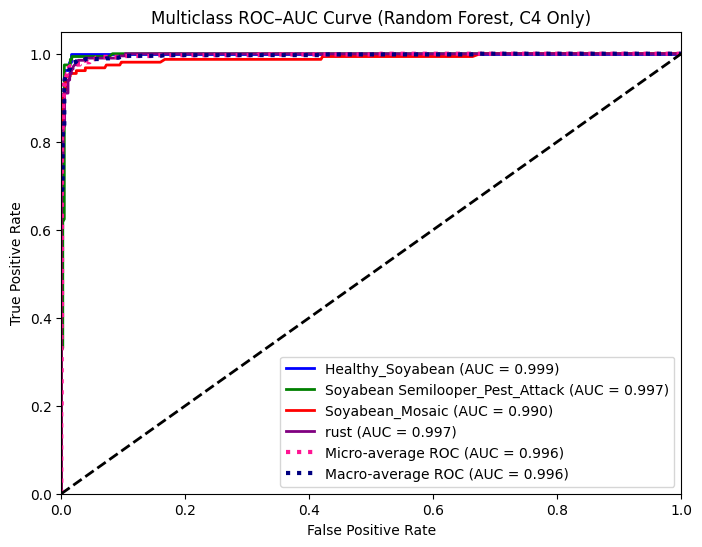

ROC-AUC curve plotted successfully.


In [13]:
num_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(test_labels, classes=range(num_classes))
y_pred_proba = rf_pred_probs_c4

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))
colors = ["blue", "green", "red", "purple"]
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (Random Forest, C4 Only)")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC curve plotted successfully.")